# NeuroScope AI - Notebook 17: Longitudinal Tracker

Tracks tumor change over time across serial scans.

**What this notebook builds:**
1. Deformable registration -- align current scan to prior scans
2. Tumor volume measurement -- cm3 from segmentation masks
3. Growth rate computation -- cm3/month with trajectory prediction
4. RECIST/RANO criteria -- automated response assessment
5. New lesion detection -- flag new findings vs prior
6. Growth charts -- visualization for doctor-patient communication
7. LongitudinalTrackerAgent -- full implementation

---

## Cell 1 - Imports & Config

In [1]:
import os, sys, json, warnings
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
warnings.filterwarnings('ignore')

try:
    import SimpleITK as sitk
    SITK_AVAILABLE = True
    print(f'SimpleITK : {sitk.Version_VersionString()}')
except ImportError:
    SITK_AVAILABLE = False
    print('SimpleITK not available -- using scipy fallback for registration')

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
OUT  = os.path.join(BASE, 'outputs', 'nb17_longitudinal')
os.makedirs(OUT, exist_ok=True)
sys.path.insert(0, BASE)

print('Imports OK')

SimpleITK : 2.5.5
Imports OK


---
## Cell 2 - Image Registration

In [2]:
import numpy as np
from scipy import ndimage


def rigid_register_2d(fixed, moving):
    """
    Rigid registration of moving image to fixed image (2D).
    Uses phase correlation for translation, then optimizes rotation.
    For full 3D deformable registration use SimpleITK (NIfTI volumes).

    Returns: registered moving image, transform params
    """
    fixed_f  = fixed.astype(np.float32)
    moving_f = moving.astype(np.float32)

    # Phase correlation for translation estimate
    f1   = np.fft.fft2(fixed_f)
    f2   = np.fft.fft2(moving_f)
    cc   = np.fft.ifft2(f1 * np.conj(f2) / (np.abs(f1 * np.conj(f2)) + 1e-8))
    peak = np.unravel_index(np.abs(cc).argmax(), cc.shape)

    # Convert peak to signed shift
    H, W  = fixed_f.shape
    dy    = peak[0] if peak[0] < H // 2 else peak[0] - H
    dx    = peak[1] if peak[1] < W // 2 else peak[1] - W

    # Apply translation
    registered = ndimage.shift(moving_f, (-dy, -dx), order=1)

    return registered, {'dy': int(dy), 'dx': int(dx)}


def deformable_register_sitk(fixed_path, moving_path, output_path=None):
    """
    Full deformable registration using SimpleITK B-spline transform.
    Used for aligning serial MRI volumes for longitudinal comparison.
    Handles scanner position, patient repositioning, breathing variation.
    """
    if not SITK_AVAILABLE:
        return None, 'SimpleITK not available'

    fixed  = sitk.ReadImage(fixed_path,  sitk.sitkFloat32)
    moving = sitk.ReadImage(moving_path, sitk.sitkFloat32)

    # Multi-resolution B-spline registration
    reg = sitk.ImageRegistrationMethod()

    # Metric: Mattes mutual information (works across scanner types)
    reg.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)
    reg.SetMetricSamplingStrategy(reg.RANDOM)
    reg.SetMetricSamplingPercentage(0.01)

    # Optimizer
    reg.SetOptimizerAsGradientDescent(
        learningRate=1.0, numberOfIterations=100,
        convergenceMinimumValue=1e-6, convergenceWindowSize=10
    )
    reg.SetOptimizerScalesFromPhysicalShift()

    # Multi-resolution
    reg.SetShrinkFactorsPerLevel(shrinkFactors=[4, 2, 1])
    reg.SetSmoothingSigmasPerLevel(smoothingSigmas=[2, 1, 0])
    reg.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

    # B-spline transform
    transform_domain_mesh_size = [8] * fixed.GetDimension()
    tx = sitk.BSplineTransformInitializer(fixed, transform_domain_mesh_size)
    reg.SetInitialTransform(tx, inPlace=False)
    reg.SetInterpolator(sitk.sitkLinear)

    final_transform = reg.Execute(fixed, moving)

    # Resample moving to fixed space
    resampled = sitk.Resample(
        moving, fixed, final_transform,
        sitk.sitkLinear, 0.0, moving.GetPixelID()
    )

    if output_path:
        sitk.WriteImage(resampled, output_path)

    return resampled, final_transform


# Demo rigid registration on synthetic images
np.random.seed(42)
H, W = 128, 128

# Simulate baseline tumor scan
baseline = np.zeros((H, W), dtype=np.float32)
baseline[50:70, 55:75] = 0.8   # tumor region
baseline += np.random.randn(H, W) * 0.05

# Simulate follow-up scan -- slightly shifted (patient repositioning)
followup = ndimage.shift(baseline.copy(), (3, -2)) * 1.1   # shifted + slightly larger
followup[52:72, 53:78] = 0.85   # tumor grew slightly

registered, transform = rigid_register_2d(baseline, followup)

print(f'Registration transform: dy={transform["dy"]}, dx={transform["dx"]}')
print(f'Baseline range  : [{baseline.min():.3f}, {baseline.max():.3f}]')
print(f'Follow-up range : [{followup.min():.3f}, {followup.max():.3f}]')
print(f'Registered range: [{registered.min():.3f}, {registered.max():.3f}]')
print('Registration OK')

Registration transform: dy=-3, dx=2
Baseline range  : [-0.196, 0.969]
Follow-up range : [-0.216, 0.993]
Registered range: [-0.216, 0.993]
Registration OK


---
## Cell 3 - Tumor Volume & Growth Rate

In [3]:
import numpy as np
from datetime import datetime


def compute_tumor_volume(mask, voxel_spacing_mm=(1.0, 1.0, 1.0)):
    """
    Compute tumor volume in cm3 from binary segmentation mask.

    volume = n_voxels * voxel_volume
    voxel_volume = dx * dy * dz mm3 -> /1000 to get cm3

    For 2D masks: assumes 1mm slice thickness.
    For real DICOM: use pixel spacing + slice thickness from metadata.
    """
    n_voxels     = int((mask > 0.5).sum())
    voxel_vol_mm3= np.prod(voxel_spacing_mm)
    volume_cm3   = n_voxels * voxel_vol_mm3 / 1000.0
    return volume_cm3


def compute_longest_diameter(mask):
    """
    Compute longest diameter of tumor mask in pixels.
    Used for RECIST measurements.
    """
    coords = np.argwhere(mask > 0.5)
    if len(coords) < 2:
        return 0.0

    # Brute force for small masks -- use convex hull for large
    if len(coords) < 1000:
        max_dist = 0.0
        for i in range(len(coords)):
            dists    = np.linalg.norm(coords[i] - coords, axis=1)
            max_dist = max(max_dist, dists.max())
        return float(max_dist)
    else:
        # Approximate via bounding box diagonal
        lo = coords.min(axis=0)
        hi = coords.max(axis=0)
        return float(np.linalg.norm(hi - lo))


def compute_growth_rate(timepoints):
    """
    Compute tumor growth rate from a list of volume measurements.

    timepoints: list of {'date': 'YYYY-MM-DD', 'volume_cm3': float}
    Returns: growth_rate_cm3_per_month, doubling_time_months, trajectory

    trajectory: 'regressing' | 'stable' | 'slow_growth' | 'rapid_growth'
    """
    if len(timepoints) < 2:
        return {'error': 'Need at least 2 timepoints'}

    # Sort by date
    pts = sorted(timepoints, key=lambda x: x['date'])

    dates   = [datetime.strptime(p['date'], '%Y-%m-%d') for p in pts]
    volumes = [p['volume_cm3'] for p in pts]

    # Months between first and last
    delta_days   = (dates[-1] - dates[0]).days
    delta_months = delta_days / 30.44

    if delta_months < 0.1:
        return {'error': 'Timepoints too close'}

    # Linear growth rate
    growth_rate = (volumes[-1] - volumes[0]) / delta_months

    # Exponential doubling time (if growing)
    doubling_time = None
    if volumes[-1] > volumes[0] and volumes[0] > 0:
        try:
            k = np.log(volumes[-1] / volumes[0]) / delta_months
            doubling_time = np.log(2) / k if k > 0 else None
        except Exception:
            pass

    # Trajectory classification
    pct_change = (volumes[-1] - volumes[0]) / max(volumes[0], 0.001) * 100
    if pct_change < -20:
        trajectory = 'regressing'
    elif pct_change < 5:
        trajectory = 'stable'
    elif pct_change < 25:
        trajectory = 'slow_growth'
    else:
        trajectory = 'rapid_growth'

    return {
        'growth_rate_cm3_per_month': round(growth_rate, 4),
        'doubling_time_months'     : round(float(doubling_time), 1) if doubling_time else None,
        'pct_change'               : round(pct_change, 1),
        'trajectory'               : trajectory,
        'first_volume'             : volumes[0],
        'last_volume'              : volumes[-1],
        'n_timepoints'             : len(pts),
        'delta_months'             : round(delta_months, 1),
    }


# Demo
demo_timepoints = [
    {'date': '2024-01-15', 'volume_cm3': 8.2},
    {'date': '2024-04-10', 'volume_cm3': 9.1},
    {'date': '2024-07-22', 'volume_cm3': 10.8},
    {'date': '2024-10-05', 'volume_cm3': 13.2},
]

growth = compute_growth_rate(demo_timepoints)
print('Tumor growth analysis:')
for k, v in growth.items():
    print(f'  {k:30s}: {v}')
print('Growth rate computation OK')

Tumor growth analysis:
  growth_rate_cm3_per_month     : 0.5765
  doubling_time_months          : 12.6
  pct_change                    : 61.0
  trajectory                    : rapid_growth
  first_volume                  : 8.2
  last_volume                   : 13.2
  n_timepoints                  : 4
  delta_months                  : 8.7
Growth rate computation OK


---
## Cell 4 - RECIST/RANO Criteria

In [4]:
import numpy as np


def recist_response(baseline_mm, followup_mm):
    """
    RECIST 1.1 response assessment.
    Measures longest diameter of target lesions.

    CR  = Complete Response   : all target lesions disappeared
    PR  = Partial Response    : >=30% decrease in sum of diameters
    PD  = Progressive Disease : >=20% increase in sum (min 5mm absolute)
    SD  = Stable Disease      : between PR and PD
    """
    if followup_mm == 0:
        return {'response': 'CR', 'change_pct': -100.0,
                'change_mm': -baseline_mm, 'criteria': 'RECIST 1.1'}

    change_mm  = followup_mm - baseline_mm
    change_pct = change_mm / baseline_mm * 100

    if change_pct <= -30:
        response = 'PR'
    elif change_pct >= 20 and change_mm >= 5:
        response = 'PD'
    else:
        response = 'SD'

    return {
        'response'  : response,
        'change_pct': round(change_pct, 1),
        'change_mm' : round(change_mm, 1),
        'baseline_mm': baseline_mm,
        'followup_mm': followup_mm,
        'criteria'  : 'RECIST 1.1',
    }


def rano_response(baseline_cm2, followup_cm2, new_lesion=False,
                   steroid_stable=True):
    """
    RANO criteria for brain tumor response assessment.
    Uses bi-dimensional measurement (product of two largest diameters).

    CR  = Complete Response   : no enhancing tumor, stable/reduced steroids
    PR  = Partial Response    : >=50% decrease in bidimensional product
    PD  = Progressive Disease : >=25% increase OR new lesion
    SD  = Stable Disease      : between PR and PD
    """
    if new_lesion:
        return {'response': 'PD', 'reason': 'New lesion detected',
                'criteria': 'RANO'}

    if followup_cm2 == 0 and steroid_stable:
        return {'response': 'CR', 'change_pct': -100.0, 'criteria': 'RANO'}

    change_pct = (followup_cm2 - baseline_cm2) / baseline_cm2 * 100

    if change_pct <= -50:
        response = 'PR'
    elif change_pct >= 25:
        response = 'PD'
    else:
        response = 'SD'

    return {
        'response'    : response,
        'change_pct'  : round(change_pct, 1),
        'baseline_cm2': baseline_cm2,
        'followup_cm2': followup_cm2,
        'criteria'    : 'RANO',
    }


# Demo
print('RECIST 1.1 examples:')
cases = [
    (30, 18, 'Partial Response expected'),
    (30, 38, 'Progressive Disease expected'),
    (30, 28, 'Stable Disease expected'),
    (30, 0,  'Complete Response expected'),
]
for bl, fu, expected in cases:
    r = recist_response(bl, fu)
    print(f'  {bl}mm -> {fu}mm : {r["response"]:3s} ({r["change_pct"]:+.0f}%) -- {expected}')

print('\nRANO examples (brain):')
rano_cases = [
    (10.0, 4.0,  False, 'PR expected'),
    (10.0, 13.0, False, 'PD expected'),
    (10.0, 9.5,  False, 'SD expected'),
    (10.0, 8.0,  True,  'PD expected (new lesion)'),
]
for bl, fu, new_l, expected in rano_cases:
    r = rano_response(bl, fu, new_lesion=new_l)
    print(f'  {bl} -> {fu} cm2 : {r["response"]:3s} -- {expected}')

print('RECIST/RANO OK')

RECIST 1.1 examples:
  30mm -> 18mm : PR  (-40%) -- Partial Response expected
  30mm -> 38mm : PD  (+27%) -- Progressive Disease expected
  30mm -> 28mm : SD  (-7%) -- Stable Disease expected
  30mm -> 0mm : CR  (-100%) -- Complete Response expected

RANO examples (brain):
  10.0 -> 4.0 cm2 : PR  -- PR expected
  10.0 -> 13.0 cm2 : PD  -- PD expected
  10.0 -> 9.5 cm2 : SD  -- SD expected
  10.0 -> 8.0 cm2 : PD  -- PD expected (new lesion)
RECIST/RANO OK


---
## Cell 5 - New Lesion Detection

In [6]:
import numpy as np
from scipy import ndimage


def detect_new_lesions(baseline_mask, followup_mask,
                        min_lesion_voxels=10, registered=True):
    base_bin = (baseline_mask > 0.5).astype(np.uint8)
    fu_bin   = (followup_mask  > 0.5).astype(np.uint8)

    new_regions = np.clip(fu_bin - base_bin, 0, 1)

    struct  = ndimage.generate_binary_structure(new_regions.ndim, 1)
    cleaned = ndimage.binary_opening(new_regions, structure=struct).astype(np.uint8)

    labeled, n_components = ndimage.label(cleaned)

    new_lesions = []
    for i in range(1, n_components + 1):
        component = (labeled == i).astype(np.int32)   # fix: cast to int32
        n_voxels  = int(component.sum())
        if n_voxels < min_lesion_voxels:
            continue
        centroid = ndimage.center_of_mass(component)
        bbox     = ndimage.find_objects(component)[0]
        new_lesions.append({
            'lesion_id'  : i,
            'n_voxels'   : n_voxels,
            'centroid'   : [round(c, 1) for c in centroid],
            'volume_cm3' : round(n_voxels * 1.0 / 1000, 4),
        })

    return {
        'n_new_lesions': len(new_lesions),
        'lesions'      : new_lesions,
        'new_voxels'   : int(cleaned.sum()),
    }


# Demo
np.random.seed(42)
H, W = 128, 128

base_mask = np.zeros((H, W))
base_mask[50:65, 55:70] = 1.0   # existing tumor

fu_mask = base_mask.copy()
fu_mask[50:67, 55:73] = 1.0   # existing tumor grew slightly
fu_mask[90:100, 20:32] = 1.0  # NEW lesion (metastasis)

result = detect_new_lesions(base_mask, fu_mask, min_lesion_voxels=5)
print(f'New lesion detection:')
print(f'  New lesions found : {result["n_new_lesions"]}')
for l in result['lesions']:
    print(f'  Lesion {l["lesion_id"]}: {l["n_voxels"]} voxels, '
          f'centroid={l["centroid"]}, vol={l["volume_cm3"]}cm3')
print('New lesion detection OK')

New lesion detection:
  New lesions found : 2
  Lesion 1: 49 voxels, centroid=[np.float64(58.3), np.float64(70.9)], vol=0.049cm3
  Lesion 2: 116 voxels, centroid=[np.float64(94.5), np.float64(25.5)], vol=0.116cm3
New lesion detection OK


---
## Cell 6 - Growth Charts & Visualization

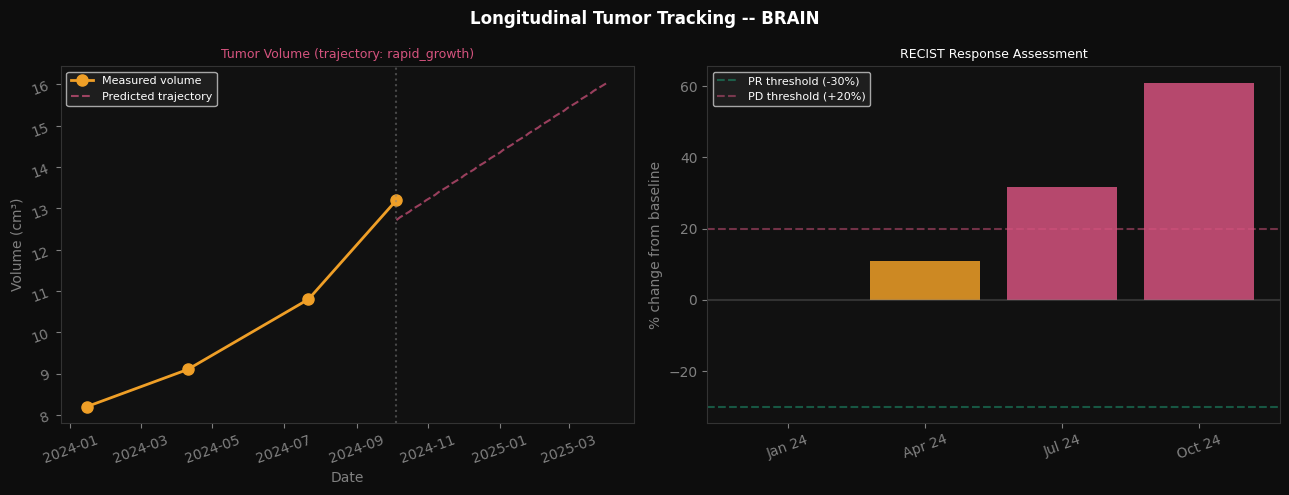

Growth chart saved
Trajectory: rapid_growth
Growth rate: 0.5765 cm3/month
Doubling time: 12.6 months


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
OUT  = os.path.join(BASE, 'outputs', 'nb17_longitudinal')


def plot_growth_chart(timepoints, patient_id='demo',
                      cancer_type='brain', save_path=None):
    """
    Generate tumor growth chart for doctor-patient communication.
    Shows actual measurements + trend line + trajectory prediction.
    """
    dates   = [datetime.strptime(p['date'], '%Y-%m-%d') for p in timepoints]
    volumes = [p['volume_cm3'] for p in timepoints]
    days    = [(d - dates[0]).days for d in dates]

    # Fit linear trend
    if len(days) >= 2:
        coeffs = np.polyfit(days, volumes, 1)
        trend  = np.poly1d(coeffs)

        # Predict next 180 days
        future_days   = np.linspace(days[-1], days[-1] + 180, 50)
        future_vols   = trend(future_days)
        future_dates  = [dates[0] + timedelta(days=int(d)) for d in future_days]
    else:
        trend, future_dates, future_vols = None, [], []

    plt.style.use('dark_background')
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#0d0d0d')
    fig.suptitle(f'Longitudinal Tumor Tracking -- {cancer_type.upper()}',
                 color='white', fontsize=12, fontweight='bold')

    # Volume over time
    ax = axes[0]
    ax.plot(dates, volumes, 'o-', color='#EF9F27', linewidth=2,
            markersize=8, label='Measured volume')
    if future_dates:
        ax.plot(future_dates, future_vols, '--', color='#D4537E',
                linewidth=1.5, alpha=0.7, label='Predicted trajectory')
        ax.axvline(dates[-1], color='gray', linestyle=':', alpha=0.5)

    # RECIST response annotations
    growth = compute_growth_rate(timepoints)
    traj   = growth.get('trajectory', 'unknown')
    traj_color = {'regressing': '#1D9E75', 'stable': '#7F77DD',
                  'slow_growth': '#EF9F27', 'rapid_growth': '#D4537E'}.get(traj, 'gray')

    ax.set_title(f'Tumor Volume (trajectory: {traj})',
                 color=traj_color, fontsize=9)
    ax.set_xlabel('Date', color='gray')
    ax.set_ylabel('Volume (cm³)', color='gray')
    ax.legend(facecolor='#222', labelcolor='white', fontsize=8)
    ax.set_facecolor('#111')
    ax.spines[:].set_color('#333')
    ax.tick_params(colors='gray', rotation=20)

    # % change waterfall
    ax2 = axes[1]
    if len(volumes) >= 2:
        pct_changes = [(volumes[i] - volumes[0]) / volumes[0] * 100
                       for i in range(len(volumes))]
        bar_colors  = ['#1D9E75' if p <= -20 else '#EF9F27'
                       if p <= 20 else '#D4537E' for p in pct_changes]
        ax2.bar(range(len(dates)), pct_changes, color=bar_colors, alpha=0.85)
        ax2.axhline(-30, color='#1D9E75', linestyle='--', alpha=0.5, label='PR threshold (-30%)')
        ax2.axhline(+20, color='#D4537E', linestyle='--', alpha=0.5, label='PD threshold (+20%)')
        ax2.set_xticks(range(len(dates)))
        ax2.set_xticklabels([d.strftime('%b %y') for d in dates], rotation=20)
        ax2.set_ylabel('% change from baseline', color='gray')
        ax2.set_title('RECIST Response Assessment', color='white', fontsize=9)
        ax2.legend(facecolor='#222', labelcolor='white', fontsize=8)
        ax2.axhline(0, color='gray', alpha=0.3)

    ax2.set_facecolor('#111')
    ax2.spines[:].set_color('#333')
    ax2.tick_params(colors='gray')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight', facecolor='#0d0d0d')
    plt.show()
    return growth


from datetime import timedelta

growth = plot_growth_chart(
    demo_timepoints,
    cancer_type='brain',
    save_path=os.path.join(OUT, 'growth_chart.png')
)

print(f'Growth chart saved')
print(f'Trajectory: {growth["trajectory"]}')
print(f'Growth rate: {growth["growth_rate_cm3_per_month"]} cm3/month')
if growth.get('doubling_time_months'):
    print(f'Doubling time: {growth["doubling_time_months"]} months')

---
## Cell 7 - LongitudinalTrackerAgent

In [8]:
import os, json
from datetime import datetime

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
LONG = os.path.join(BASE, 'longitudinal')
os.makedirs(LONG, exist_ok=True)


class LongitudinalTrackerAgent:
    """
    Tracks tumor evolution across serial scans for one patient.

    Stores:
      - Scan history: list of scan results with dates and volumes
      - Growth rate and trajectory
      - RECIST/RANO response assessment
      - New lesion flags
      - Growth chart path
    """

    def __init__(self, patient_id, cancer_type, storage_dir=None):
        self.patient_id  = patient_id
        self.cancer_type = cancer_type
        self.storage_dir = storage_dir or LONG
        self.history_path= os.path.join(
            self.storage_dir, f'{patient_id}_{cancer_type}_history.json'
        )
        self.history     = self._load_history()

    def _load_history(self):
        if os.path.exists(self.history_path):
            with open(self.history_path, encoding='utf-8') as f:
                return json.load(f)
        return []

    def _save_history(self):
        with open(self.history_path, 'w', encoding='utf-8') as f:
            json.dump(self.history, f, indent=2, ensure_ascii=False)

    def add_scan(self, scan_date, volume_cm3, longest_diameter_mm=None,
                 scan_id=None, mask=None, notes=''):
        """
        Add a new scan to patient history.
        Returns comparison with previous scan if available.
        """
        entry = {
            'date'                : scan_date,
            'volume_cm3'          : volume_cm3,
            'longest_diameter_mm' : longest_diameter_mm,
            'scan_id'             : scan_id,
            'notes'               : notes,
            'added_at'            : datetime.now().isoformat(),
        }

        comparison = None
        if self.history:
            prev = self.history[-1]

            # RECIST assessment
            if longest_diameter_mm and prev.get('longest_diameter_mm'):
                recist = recist_response(
                    prev['longest_diameter_mm'], longest_diameter_mm
                )
            else:
                recist = None

            # RANO for brain
            rano = None
            if self.cancer_type == 'brain' and volume_cm3 and prev.get('volume_cm3'):
                rano = rano_response(
                    prev['volume_cm3'], volume_cm3
                )

            comparison = {
                'vs_scan_date'  : prev['date'],
                'recist'        : recist,
                'rano'          : rano,
                'volume_change' : round(volume_cm3 - prev['volume_cm3'], 3)
                                  if prev.get('volume_cm3') else None,
            }
            entry['comparison'] = comparison

        self.history.append(entry)
        self._save_history()
        return entry, comparison

    def get_trajectory(self):
        """Compute current growth trajectory from full history."""
        if len(self.history) < 2:
            return {'status': 'insufficient_data'}
        timepoints = [{'date': h['date'], 'volume_cm3': h['volume_cm3']}
                      for h in self.history if h.get('volume_cm3')]
        return compute_growth_rate(timepoints)

    def generate_chart(self, out_dir=None):
        """Generate growth chart for this patient."""
        timepoints = [{'date': h['date'], 'volume_cm3': h['volume_cm3']}
                      for h in self.history if h.get('volume_cm3')]
        if len(timepoints) < 2:
            return None
        save_path = os.path.join(
            out_dir or self.storage_dir,
            f'{self.patient_id}_growth_chart.png'
        )
        plot_growth_chart(timepoints, self.patient_id,
                          self.cancer_type, save_path)
        return save_path

    def summary(self):
        """Text summary of longitudinal tracking."""
        traj = self.get_trajectory()
        lines = [
            f'Patient     : {self.patient_id}',
            f'Cancer      : {self.cancer_type}',
            f'Scans       : {len(self.history)}',
        ]
        if self.history:
            lines.append(f'First scan  : {self.history[0]["date"]}')
            lines.append(f'Latest scan : {self.history[-1]["date"]}')
            lines.append(f'Latest vol  : {self.history[-1].get("volume_cm3")} cm3')
        if 'trajectory' in traj:
            lines.append(f'Trajectory  : {traj["trajectory"]}')
            lines.append(f'Growth rate : {traj["growth_rate_cm3_per_month"]} cm3/mo')
        return '\n'.join(lines)


# Test tracker
tracker = LongitudinalTrackerAgent('PT_GBM_001', 'brain',
                                    storage_dir=os.path.join(BASE, 'outputs', 'nb17_longitudinal'))

scan_data = [
    ('2024-01-15', 8.2,  42.1, 'SCAN_001', 'Baseline pre-treatment'),
    ('2024-04-10', 9.1,  44.8, 'SCAN_002', 'Post-RT cycle 1'),
    ('2024-07-22', 10.8, 48.2, 'SCAN_003', 'Post-TMZ cycle 3'),
    ('2024-10-05', 13.2, 52.1, 'SCAN_004', 'Follow-up'),
]

print('Adding scans to tracker...')
for date, vol, diam, scan_id, notes in scan_data:
    entry, comp = tracker.add_scan(date, vol, diam, scan_id, notes=notes)
    if comp and comp.get('recist'):
        r = comp['recist']
        print(f'  {date}: vol={vol} cm3, RECIST={r["response"]} ({r["change_pct"]:+.0f}%)')
    else:
        print(f'  {date}: vol={vol} cm3 (baseline)')

print()
print(tracker.summary())
print('\nLongitudinalTrackerAgent OK')

Adding scans to tracker...
  2024-01-15: vol=8.2 cm3 (baseline)
  2024-04-10: vol=9.1 cm3, RECIST=SD (+6%)
  2024-07-22: vol=10.8 cm3, RECIST=SD (+8%)
  2024-10-05: vol=13.2 cm3, RECIST=SD (+8%)

Patient     : PT_GBM_001
Cancer      : brain
Scans       : 4
First scan  : 2024-01-15
Latest scan : 2024-10-05
Latest vol  : 13.2 cm3
Trajectory  : rapid_growth
Growth rate : 0.5765 cm3/mo

LongitudinalTrackerAgent OK


---
## Cell 8 - Summary

In [9]:
import os

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
OUT  = os.path.join(BASE, 'outputs', 'nb17_longitudinal')

print('=' * 65)
print('  NOTEBOOK 17 - LONGITUDINAL TRACKER')
print('=' * 65)
print()
print('  Components built:')
print('    rigid_register_2d()         -- phase correlation alignment')
print('    deformable_register_sitk()  -- B-spline (SimpleITK)')
print('    compute_tumor_volume()      -- voxel count * spacing')
print('    compute_longest_diameter()  -- RECIST measurement')
print('    compute_growth_rate()       -- cm3/month + doubling time')
print('    recist_response()           -- RECIST 1.1 criteria')
print('    rano_response()             -- RANO brain criteria')
print('    detect_new_lesions()        -- connected component diff')
print('    plot_growth_chart()         -- volume + RECIST waterfall')
print('    LongitudinalTrackerAgent    -- full per-patient tracking')
print()
print('  Outputs:')
for f in ['growth_chart.png', 'PT_GBM_001_growth_chart.png',
          'PT_GBM_001_brain_history.json']:
    p = os.path.join(OUT, f)
    print(f'    {f:45s}: {"OK" if os.path.exists(p) else "not generated"}')
print()
print('  Next: 18_Radiomics_Digital_Twin.ipynb')
print('    - pyradiomics 1000+ feature extraction')
print('    - NSCLC-Radiomics feature analysis')
print('    - Treatment response prediction')
print('    - Digital twin outcome simulation')
print('=' * 65)

  NOTEBOOK 17 - LONGITUDINAL TRACKER

  Components built:
    rigid_register_2d()         -- phase correlation alignment
    deformable_register_sitk()  -- B-spline (SimpleITK)
    compute_tumor_volume()      -- voxel count * spacing
    compute_longest_diameter()  -- RECIST measurement
    compute_growth_rate()       -- cm3/month + doubling time
    recist_response()           -- RECIST 1.1 criteria
    rano_response()             -- RANO brain criteria
    detect_new_lesions()        -- connected component diff
    plot_growth_chart()         -- volume + RECIST waterfall
    LongitudinalTrackerAgent    -- full per-patient tracking

  Outputs:
    growth_chart.png                             : OK
    PT_GBM_001_growth_chart.png                  : not generated
    PT_GBM_001_brain_history.json                : OK

  Next: 18_Radiomics_Digital_Twin.ipynb
    - pyradiomics 1000+ feature extraction
    - NSCLC-Radiomics feature analysis
    - Treatment response prediction
    - Digital t